## Import and load the data

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
import h5py

def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

dir = "/Users/stijnroos/VisualStudio/DL_data/"
filename_path = dir + "Intra/train/rest_105923_1.h5"

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)

<class 'numpy.ndarray'>
(248, 35624)


## Data visualisation

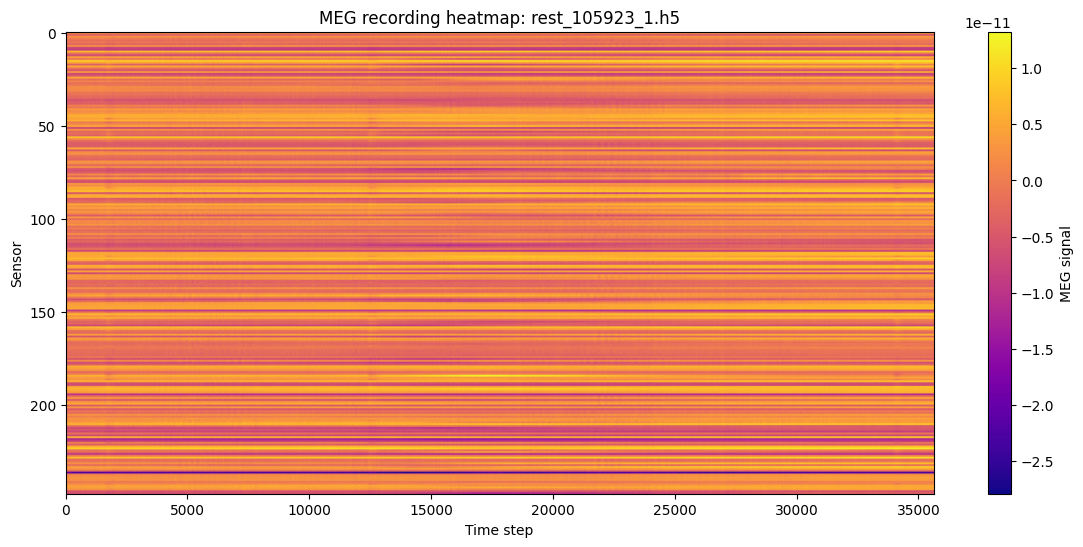

In [ ]:
# plot a single observation as a heatmap
plt.figure(figsize=(14, 6))
plt.imshow(matrix, aspect="auto", cmap="plasma")
plt.colorbar(label="MEG signal")
plt.xlabel("Time step")
plt.ylabel("Sensor")
plt.title(f"MEG recording heatmap: {os.path.basename(filename_path)}")
plt.show()

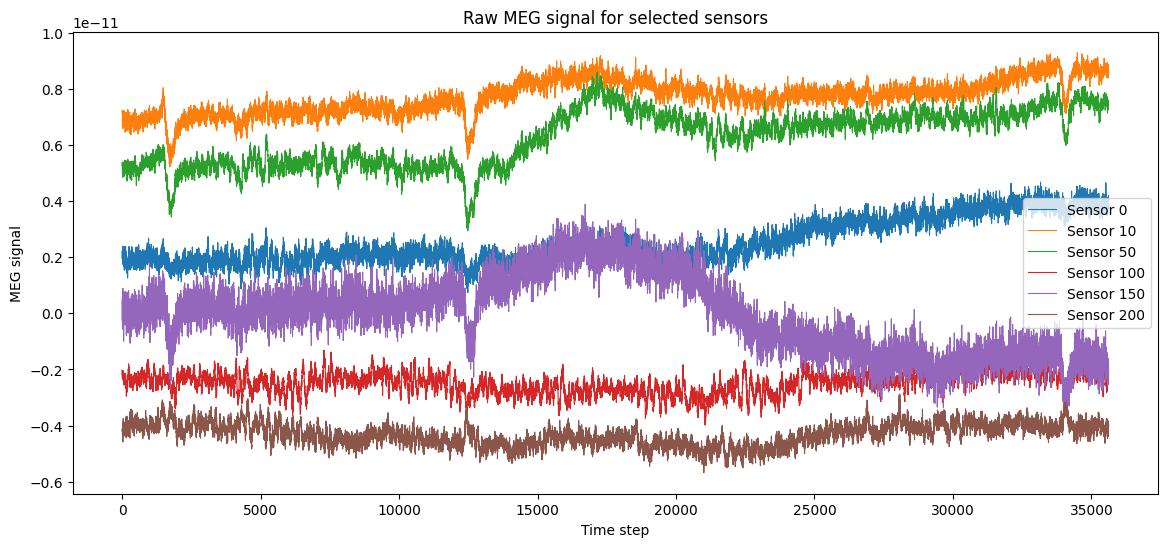

In [ ]:
sensor_ids = [0, 10, 50, 100, 150, 200]

plt.figure(figsize=(14, 6))
for sensor_id in sensor_ids:
    plt.plot(matrix[sensor_id], label=f"Sensor {sensor_id}", linewidth=0.8)

plt.xlabel("Time step")
plt.ylabel("MEG signal")
plt.title("Raw MEG signal for random sensors")
plt.legend()
plt.show()

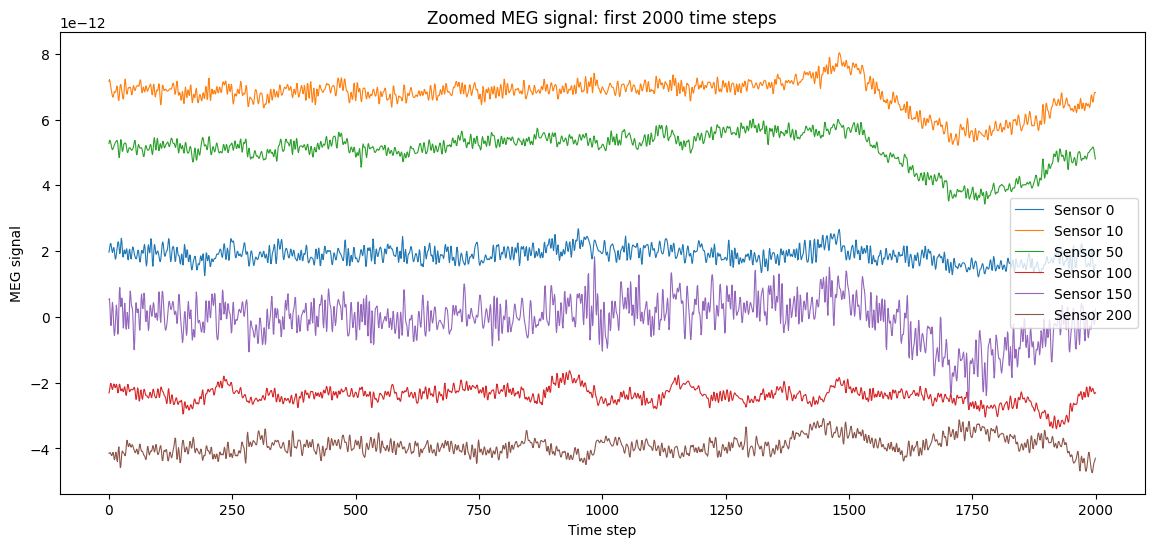

In [ ]:
# Plot the same signal but only the first 2,000
n_steps = 2000

plt.figure(figsize=(14, 6))
for sensor_id in sensor_ids:
    plt.plot(matrix[sensor_id, :n_steps], label=f"Sensor {sensor_id}", linewidth=0.8)

plt.xlabel("Time step")
plt.ylabel("MEG signal")
plt.title(f"Zoomed MEG signal: first {n_steps} time steps")
plt.legend()
plt.show()

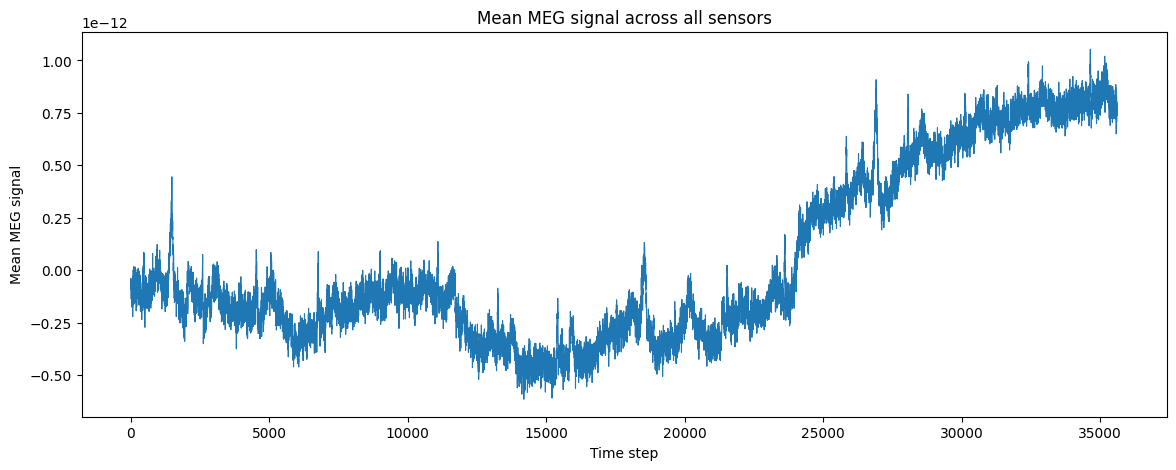

In [15]:
mean_signal = matrix.mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(mean_signal, linewidth=0.8)
plt.xlabel("Time step")
plt.ylabel("Mean MEG signal")
plt.title("Mean MEG signal across all sensors")
plt.show()

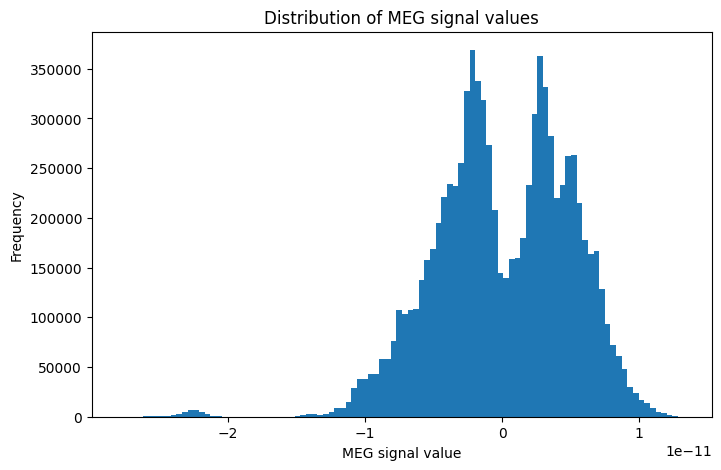

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(matrix.flatten(), bins=100)
plt.xlabel("MEG signal value")
plt.ylabel("Frequency")
plt.title("Distribution of MEG signal values")
plt.show()

---
## Model training